In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [3]:
x

array([50, 60, 70, 80, 90])

In [4]:
y

array([150, 180, 210, 240, 270])

In [5]:
x_mean = x.mean()
x_std = x.std()
x_norm = (x - x_mean) / x_std
x_norm

array([-1.41421356, -0.70710678,  0.        ,  0.70710678,  1.41421356])

In [6]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.0001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_values = []

    def fit(self, X, y):
        n = len(X)
        self.n_samples = n
        self.sse_values = []

        for i in range(self.n_iters):
            y_hat = self.theta_0 + self.theta_1 * X

            D_theta_0 = 2 * np.sum(y_hat - y) / n
            D_theta_1 = 2 * np.sum((y_hat - y) * X) / n

            self.theta_0 -= self.learning_rate * D_theta_0
            self.theta_1 -= self.learning_rate * D_theta_1

            sse = np.sum((y_hat - y) ** 2)
            self.sse_values.append(sse)

            if (i + 1) % 20 == 0 or i == 0:
                print(f"iteration {i+1}, SSE: {sse:.4f}")

    def predict(self, X_input):
        return self.theta_0 + self.theta_1 * X_input

    def calculate_mse(self):
        if not self.sse_values:
            return None
        return self.sse_values[-1] / self.n_samples

    def plot_training(self, X_raw, X_input, y):
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(range(1, self.n_iters + 1), self.sse_values, label='SSE', color='blue')
        plt.xlabel("Iteration")
        plt.ylabel("SSE")
        plt.title("SSE over Iteration")
        plt.legend()
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.scatter(X_raw, y, color="blue", label='Data Points')
        plt.plot(X_raw, self.predict(X_input), color='red', label='Regression Line')
        plt.xlabel("X (House Size m²)")
        plt.ylabel("Y (Price in Thousands)")
        plt.title("Linear Regression Fit Line")
        plt.legend()
        plt.grid()

        plt.show()

In [7]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(x_norm, y)

iteration 1, SSE: 229500.0000
iteration 20, SSE: 212688.1329
iteration 40, SSE: 196320.1650
iteration 60, SSE: 181211.8365
iteration 80, SSE: 167266.2087
iteration 100, SSE: 154393.8030


In [8]:
print(f"Optimized parameters: theta_0 (bias) = {model.theta_0:.4f}, theta_1 (slope) = {model.theta_1:.4f}")

Optimized parameters: theta_0 (bias) = 38.1010, theta_1 (slope) = 7.6976


In [9]:
mse = model.calculate_mse()
print(f"Mean Squared Error (MSE): {mse:.4f}")

Mean Squared Error (MSE): 30878.7606


In [10]:
X_new = 70
X_new_norm = (X_new - x_mean) / x_std
predicted_price = model.predict(X_new_norm)
print(f"Predicted price for size {X_new} m² is: {predicted_price:.2f} thousand")

Predicted price for size 70 m² is: 38.10 thousand


In [11]:
check_model = LinearRegressionGD(learning_rate=0.1, n_iters=100)
check_model.fit(x_norm, y)
check_pred = check_model.predict((70 - x_mean) / x_std)
print(f"[Check] Final SSE: {check_model.sse_values[-1]:.6f}")
print(f"[Check] Predicted price for 70 m² with lr=0.1: {check_pred:.2f} thousand")

iteration 1, SSE: 229500.0000
iteration 20, SSE: 47.6653
iteration 40, SSE: 0.0063
iteration 60, SSE: 0.0000
iteration 80, SSE: 0.0000
iteration 100, SSE: 0.0000
[Check] Final SSE: 0.000000
[Check] Predicted price for 70 m² with lr=0.1: 210.00 thousand


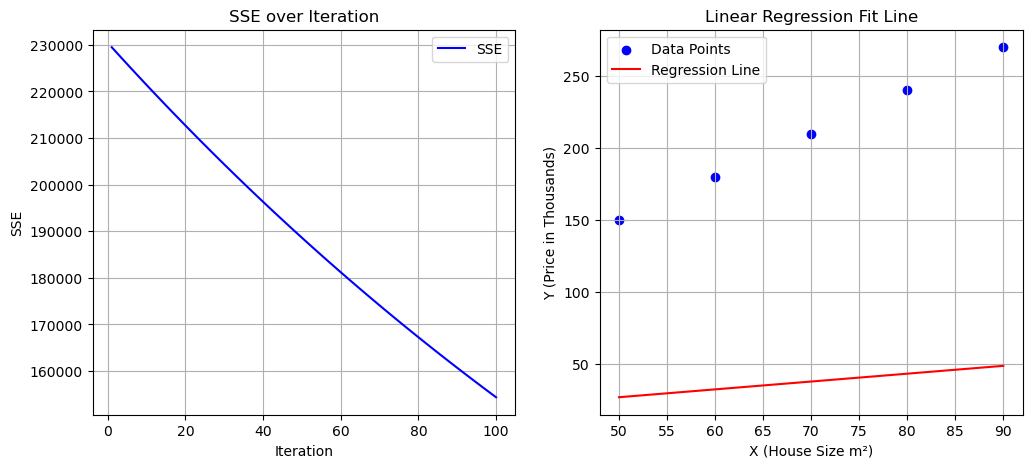

In [12]:
model.plot_training(x, x_norm, y)

In [13]:
model_large_lr = LinearRegressionGD(learning_rate=1.5, n_iters=100)
model_large_lr.fit(x_norm, y)
print("Final SSE (large LR = 1.5):", model_large_lr.sse_values[-1])

iteration 1, SSE: 229500.0000
iteration 20, SSE: 63084479643648000.0000
iteration 40, SSE: 69362118900389348898766848000.0000
iteration 60, SSE: 76264456258159538536449373166551372398592.0000
iteration 80, SSE: 83853656441860544298112450997769755022302647410491392.0000
iteration 100, SSE: 92198070289359555367206976400850858690232735038023581677956104192.0000
Final SSE (large LR = 1.5): 9.219807028935956e+64


In [14]:
model_small_lr = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_small_lr.fit(x_norm, y)
print("Final SSE (small LR = 0.00001):", model_small_lr.sse_values[-1])

iteration 1, SSE: 229500.0000
iteration 20, SSE: 229325.6445
iteration 40, SSE: 229142.2555
iteration 60, SSE: 228959.0132
iteration 80, SSE: 228775.9174
iteration 100, SSE: 228592.9680
Final SSE (small LR = 0.00001): 228592.96803825535


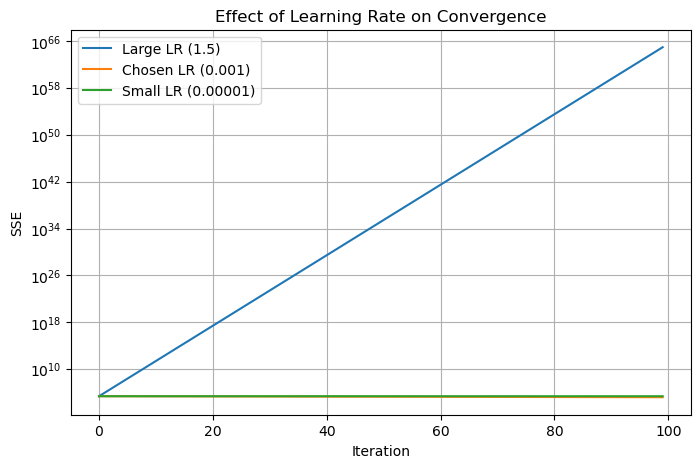

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(model_large_lr.sse_values, label="Large LR (1.5)")
plt.plot(model.sse_values, label="Chosen LR (0.001)")
plt.plot(model_small_lr.sse_values, label="Small LR (0.00001)")
plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.yscale("log")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.grid()
plt.show()

In [16]:
class LinearRegressionGD_Multi:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.sse_values = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.n_samples = n_samples
        X_b = np.c_[np.ones(n_samples), X]
        self.theta = np.zeros(n_features + 1)
        self.sse_values = []

        for i in range(self.n_iters):
            y_hat = X_b.dot(self.theta)
            gradients = 2 * X_b.T.dot(y_hat - y) / n_samples
            self.theta -= self.learning_rate * gradients

            sse = np.sum((y_hat - y) ** 2)
            self.sse_values.append(sse)

            if (i + 1) % 200 == 0 or i == 0:
                print(f"iteration {i+1}, SSE: {sse:.4f}")

    def predict(self, X):
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b.dot(self.theta)

    def calculate_mse(self):
        if not self.sse_values:
            return None
        return self.sse_values[-1] / len(self.sse_values)

In [17]:
X_multi = np.array([
    [50, 2],
    [60, 3],
    [70, 3],
    [80, 4],
    [90, 4]
], dtype=float)

y_multi = np.array([150, 180, 210, 240, 270])

X_multi_norm = (X_multi - X_multi.mean(axis=0)) / X_multi.std(axis=0)

model_multi = LinearRegressionGD_Multi(learning_rate=0.1, n_iters=1000)
model_multi.fit(X_multi_norm, y_multi)

print("Theta (bias + weights):", model_multi.theta)
print("MSE:", model_multi.calculate_mse())

iteration 1, SSE: 229500.0000
iteration 200, SSE: 3.0151
iteration 400, SSE: 0.0359
iteration 600, SSE: 0.0004
iteration 800, SSE: 0.0000
iteration 1000, SSE: 0.0000
Theta (bias + weights): [2.10000000e+02 4.24260795e+01 3.27414110e-04]
MSE: 6.037835146431923e-11
